# Group 1: Family Buyer
Dario, Sediqa, Rodrigo, Benjamin

---



# Setup


---



### Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Import dataset

In [2]:
df = pd.read_csv('KC_housing_data 2.csv')

### Data cleaning

In [3]:
# Find missing data
df.isna().sum()
df.loc[df.duplicated()]

df = df[ df['price'] != 0.0 ]
df = df[ df['bedrooms'] != 0.0 ]
df = df[ df['bathrooms'] != 0.0 ]

df = df.reset_index(drop=True)

df.shape

(4549, 18)

### New features

In [4]:
df['is_family_friendly'] = ((df['bedrooms'] >= 2) &
                             (df['bathrooms'] >= 2)).astype(int)

df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

df['house_age'] = df['year'] - df['yr_built']

# Small (<1500)
# Medium (1500-2500)
# Large (2500-3500)
# Very Large (3500+)
df['size_category'] = pd.cut(df['sqft_living'],
                               bins=[0, 1500, 2500, 3500, float('inf')],
                               labels=['small', 'medium',
                                       'large', 'very-large'])

# Budget (<$300K)
# Mid-Range ($300-500K)
# Upper-Mid ($500-750K)
# Luxury ($750K+)
df['price_segment'] = pd.cut(df['price'],
                               bins=[0, 300000, 500000, 750000, float('inf')],
                               labels=['budget', 'mid-range',
                                       'upper-mid', 'luxury'])

# 0-10yr
# 11-20yr
# 21-30yr
# 31-50yr
# 50-100yr
# 100+yr
age_bins = [0, 10, 20, 30, 50, 100, 150]
age_labels = ['0-10yr', '11-20yr', '21-30yr', '31-50yr', '50-100yr', '100+yr']
df['age_group'] = pd.cut(df['house_age'], bins=age_bins, labels=age_labels)

df['is_affordable'] = df['price_segment'].isin(['budget', 'mid-range']).astype(int)



df['is_renovated'] = (df['yr_renovated'].fillna(0).astype(int) > 0).astype(int)

df['is_flashy'] = ((df['waterfront'] == 1) | (df['view'] >= 3)).astype(int)

df['price_per_sqft'] = df['price'] / df['sqft_living']

engineered_features = [
    'is_family_friendly', 'year', 'month', 'house_age',
    'size_category', 'price_segment', 'age_group',
    'is_affordable', 'is_renovated', 'is_flashy',
    'price_per_sqft'
]


# Regression Models: Cases 1 and 2


---



## Case 1: SELECTED FEATURES

### Correlation of features with price

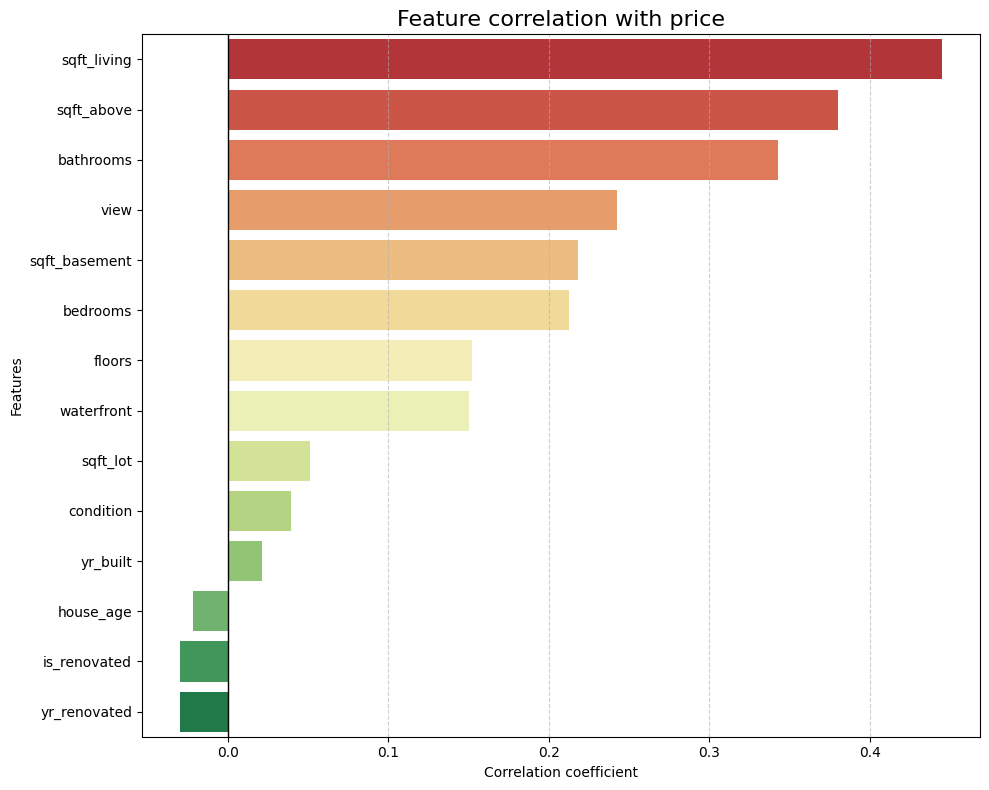

In [13]:
# Correlation plot to visualize the type of relationship that each feature has with price
numeric_df = df.select_dtypes(include=['number'])

price_correlations = numeric_df.corr()['price']

price_correlations = price_correlations.drop([
    'is_family_friendly', 'year', 'month',
    'size_category', 'price_segment', 'age_group',
    'is_affordable', 'is_flashy',
    'price_per_sqft', 'price',
], errors='ignore')

price_correlations = price_correlations.sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=price_correlations.values,
            y=price_correlations.index,
            hue=price_correlations.index,
            palette='RdYlGn',
            legend=False)

plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.title('Feature correlation with price', fontsize=16)
plt.xlabel('Correlation coefficient')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Features

In [14]:
# FEATURES FOR C1
features = ['sqft_living', 'bathrooms', 'bedrooms', 'view', 'waterfront', 'house_age', 'is_renovated', 'floors']
X = df[features]
y = df['price']

### C1: Linear Regression Model: Predicting house prices

MSE: 68,590,985,798.58


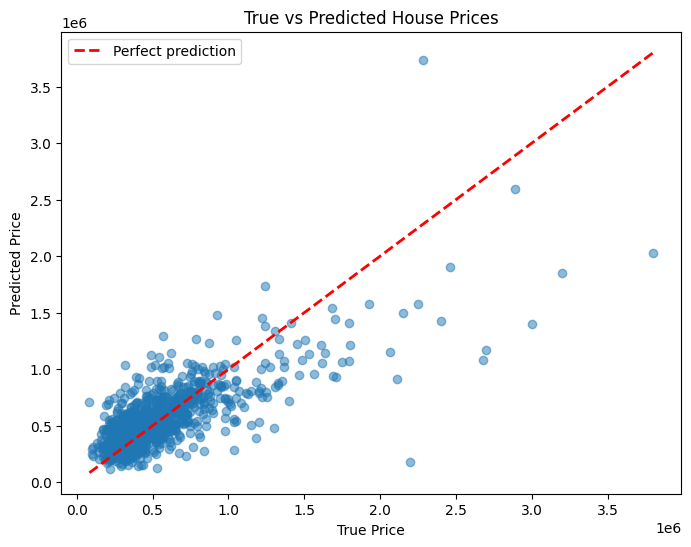

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

df_clean = df[df['price'] > 0]
X = df_clean[['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'yr_built']]
y = df_clean['price']

# 1. GETTING MODEL INSTANCE
lin_model = LinearRegression()

# 2. SPLITTING THE DATASET
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. FITTING THE LINEAR MODEL
lin_model.fit(X_train, y_train)

# 4. USING TEST DATA TO MAKE PREDICTIONS
y_pred = lin_model.predict(X_test)

# 5. CALCULATE MSE
mse = mean_squared_error(y_test, y_pred)

print(f"MSE: {mse:,.2f}")

# 6. VISUALIZATION
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('True Price')
plt.ylabel('Predicted Price')
plt.title('True vs Predicted House Prices')
plt.legend()
plt.show()

### C1: Logistic Regression Model: Classifying expensive houses

Logistic Regression Accuracy: 76.26%


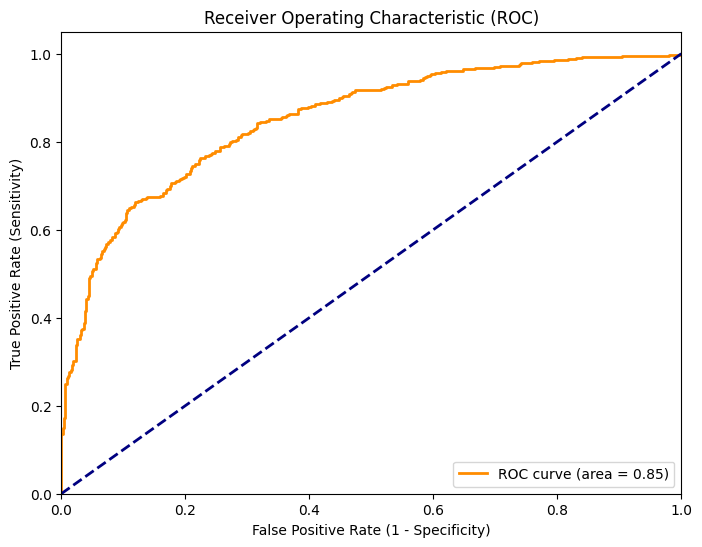

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# CREATING BINARY FEATURE: is_expensive
median_price = df_clean['price'].median()
df_clean['is_expensive'] = (df_clean['price'] > median_price).astype(int)
y_binary = df_clean['is_expensive']

# 1. GETTING INSTANCE OF THE LOGISTIC MODEL
log_model = LogisticRegression(max_iter=1000)

# 2. SPLITTING DATA
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(X, y_binary, test_size=0.2, random_state=42)

# 3. FITTING THE LOGISTIC MODEL
log_model.fit(X_train_bin, y_train_bin)

# 4. USING TEST DATA TO MAKE PREDICTIONS
y_pred_bin = log_model.predict(X_test_bin)

# 5. CALCULATE MODEL ACCURACY
accuracy = accuracy_score(y_test_bin, y_pred_bin)
print(f"Logistic Regression Accuracy: {accuracy:.2%}")

# 6. VISUALIZATION WITH CONFUSION MATRIX
#cm = confusion_matrix(y_test_bin, y_pred_bin)
#disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Affordable', 'Expensive'])
#disp.plot(cmap='Blues')
#plt.title('Confusion Matrix for House Classification')
#plt.show()

# VISUALIZATION WITH ROC
from sklearn.metrics import roc_curve, auc

# 1. PREDICTING PROBABILITIES
y_probs = log_model.predict_proba(X_test_bin)[:, 1]

# 2. CALCULATING FALSE POSITIVE RATE, TRUE POSITIVE RATE
fpr, tpr, thresholds = roc_curve(y_test_bin, y_probs)

# 3. AREA UNDER THE CURVE
roc_auc = auc(fpr, tpr)

# 4. PLOTTING
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

## Case 2: ALL FEATURES

In [17]:
features = ['price_per_sqft', 'sqft_living', 'sqft_above', 'bathrooms', 'view', 'is_family_friendly', 'sqft_basement', 'is_flashy', 'bedrooms', 'floors',
        'waterfront', 'sqft_lot', 'month', 'condition', 'yr_built', 'house_age', 'is_renovated', 'yr_renovated', 'is_affordable', 'year' ]
X = df[features]
y = df['price']

MSE: 21,199,959,625.37


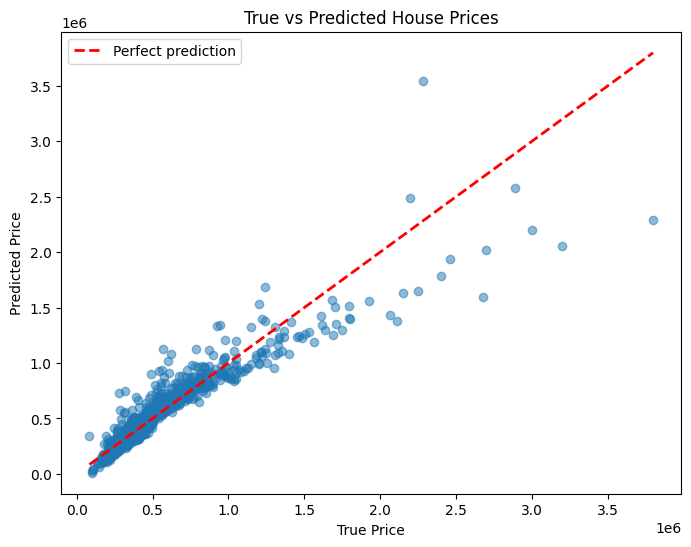

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

df_clean = df[df['price'] > 0]

# 1. GETTING MODEL INSTANCE
lin_model = LinearRegression()

# 2. SPLITTING THE DATASET
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. FITTING THE LINEAR MODEL
lin_model.fit(X_train, y_train)

# 4. USING TEST DATA TO MAKE PREDICTIONS
y_pred = lin_model.predict(X_test)

# 5. CALCULATE MSE
mse = mean_squared_error(y_test, y_pred)

print(f"MSE: {mse:,.2f}")

# 6. VISUALIZATION
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('True Price')
plt.ylabel('Predicted Price')
plt.title('True vs Predicted House Prices')
plt.legend()
plt.show()

Logistic Regression Accuracy (with Scaling): 95.38%


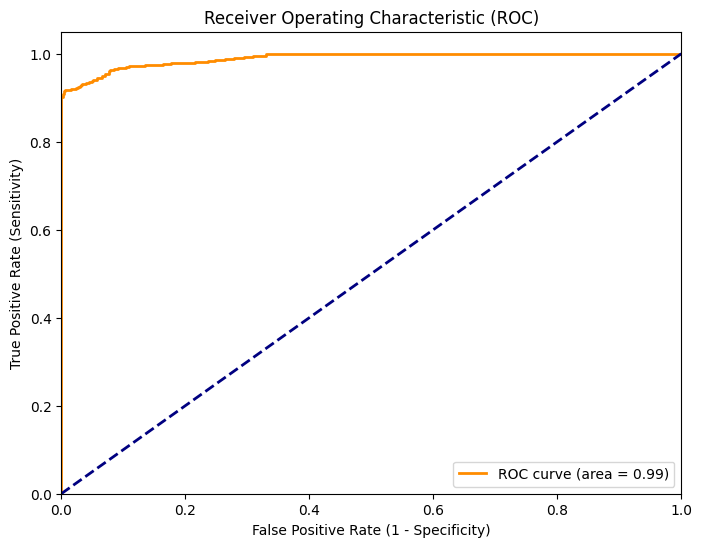

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 1. PREPARING DATA
median_price = df_clean['price'].median()
df_clean['is_expensive'] = (df_clean['price'] > median_price).astype(int)
y_binary = df_clean['is_expensive']

# 2. SPLITTING DATA
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(X, y_binary, test_size=0.2, random_state=42)

# 3. CREATING THE PIPELINE
model_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(max_iter=1000))
])

# 4. FITTING THE PIPELINE
model_pipeline.fit(X_train_bin, y_train_bin)

# 5. PREDICTING
y_pred_bin = model_pipeline.predict(X_test_bin)

# 6. EVALUATION
accuracy = accuracy_score(y_test_bin, y_pred_bin)
print(f"Logistic Regression Accuracy (with Scaling): {accuracy:.2%}")

# 7. VISUALIZATION
#cm = confusion_matrix(y_test_bin, y_pred_bin)
#disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Affordable', 'Expensive'])
#disp.plot(cmap='Blues')
#plt.title('Confusion Matrix: Scaled Logistic Regression')
#plt.show()

## VISUALIZATION WITH ROC
from sklearn.metrics import roc_curve, auc

# 1. PREDICTING PROBABILITIES
y_probs = model_pipeline.predict_proba(X_test_bin)[:, 1]

# 2. CALCULATING FALSE POSITIVE RATE, TRUE POSITIVE RATE
fpr, tpr, thresholds = roc_curve(y_test_bin, y_probs)

# 3. AREA UNDER THE CURVE
roc_auc = auc(fpr, tpr)

# 4. PLOTTING
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

## Comparison between Test 1 and 2

Both linear and logistic models in case 2 where all features were used in training provided more accurate results than less features in case 1.



# Comparison and Reflection


---



**Similarities between linear and logistic regression models:**
1.   Both linear and logistic regression models are affected by the number of features used for training. From the tests, as the number of features increased, the accuracy increased while the MSE decreased.
2.   Both are linear at core and attempt to minimize their loss functions. The can be expressed in the form *y = mx + b*




**Differences in tasks, outputs, and metrics**

**Tasks:**

Linear regression is used to predict numerical values of continuous features while logisitic regression is used to predict categorical values of discrete features. In this case, price is continous while *is_expensive* is a binomial categorical feature.

Logistic regression is affected by the magnitude of feature values. It works better when values or scaled to the smae range of 0 to 1. Otherwise, the training will always hit the maximum iterations and will not complete. Linear regression did not show this behaviour.

**Outputs:**

Linear regression models output continous numerical values while logistic regression models output categorical values i.e, either 0 or 1 based on a computed threshold value.

**Metrics:**

Linear regression models use *Root Mean Square Error (RMSE)* and optimize for a model with the least RMSE while logistic regression models utilize *accuracy* and optimize for the least log loss.

# Real-World Use Cases


---




**When to Use Linear Regression**

Linear Regression is useful when we need to predict values of continuous features. For example: Property valuation for real estate agencies

**When to Use Logistic Regression**

Logistic Regression is useful when we need to predict the category of data points, that is to say, make a decision rather than predict an exact value. For example:
* Determining if a house fits within a buyer’s budget
* Filtering listings as affordable or expensive
* Market segmentation
* Supporting buyers in narrowing down options


**Final Reflection**

Both models use the same dataset but serve different purposes. Linear Regression provides detailed price predictions with moderate accuracy. Logistic Regression simplifies the problem into affordability classification and achieved relatively strong performance.
Therefore, the choice between the two models depends on the business goal:
* If we need precise valuation, Linear Regression is more appropriate.
* If we need clear decision-making or filtering, Logistic Regression is more practical.